In [2]:
import os

os.chdir("../../../")  # Move to climate-research-workbench root
print(f"CWD: {os.getcwd()}")

CWD: c:\Users\zharif\Documents\Dataset TA


In [3]:
import datetime
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import cartopy
cartopy.config['data_dir'] = 'cache/cartopy'  # Set Cartopy data directory

In [4]:
zarr_path = "data/era5_indonesia_2018-2022.zarr"
ds_hr = xr.open_zarr(zarr_path, consolidated=True)
ds_hr

<xarray.Dataset> Size: 4GB
Dimensions:                   (time: 7304, latitude: 181, longitude: 201)
Coordinates:
  * latitude                  (latitude) float32 724B 30.0 29.75 ... -15.0
  * longitude                 (longitude) float32 804B 90.0 90.25 ... 140.0
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 201), meta=np.ndarray>
    10m_v_component_of_wind   (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 201), meta=np.ndarray>
    2m_temperature            (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 201), meta=np.ndarray>
    total_precipitation_24hr  (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 201), meta=np.ndarray>

In [5]:
import numpy as np
import xarray as xr
import xesmf as xe

# =========================================
# Truth is the constraint — build LR from HR truth
# =========================================
scale = 6

ds_hr = ds_hr.sortby("latitude")  # ensure south → north

tr_lons = ds_hr.longitude.values
tr_lats = ds_hr.latitude.values

# Pseudo-forecast grid from truth stride (Perfect Prognosis setup)
fc_lons = tr_lons[::scale]
fc_lats = tr_lats[::scale]

# ── Force start like forecast-correction notebook ──
lon_start = 90.0
lat_start = -13.5

# Snap to available pseudo-forecast coords
lon_start = float(fc_lons[np.argmin(np.abs(fc_lons - lon_start))])
lat_start = float(fc_lats[np.argmin(np.abs(fc_lats - lat_start))])

# ── Snap to truth grid indices ──
lon_start_idx = np.argmin(np.abs(tr_lons - lon_start))
lat_start_idx = np.argmin(np.abs(tr_lats - lat_start))

print(f"lon_start={lon_start}, idx={lon_start_idx}, truth={tr_lons[lon_start_idx]}")
print(f"lat_start={lat_start}, idx={lat_start_idx}, truth={tr_lats[lat_start_idx]}")

# ── Available truth points from start ──
avail_lon = len(tr_lons) - lon_start_idx
avail_lat = len(tr_lats) - lat_start_idx

# ── Max LR points truth can support ──
max_fc_lon = avail_lon // scale
max_fc_lat = avail_lat // scale

# ── Clamp to U-Net friendly size (24×32) ──
max_fc_lon = min(max_fc_lon, 32)
max_fc_lat = min(max_fc_lat, 24)

# ── Slice truth by exact count (HR target) ──
ds_tr = ds_hr.isel(
    longitude=slice(lon_start_idx, lon_start_idx + max_fc_lon * scale),
    latitude=slice(lat_start_idx, lat_start_idx + max_fc_lat * scale),
)
HIGH_LON = len(ds_tr.longitude)
HIGH_LAT = len(ds_tr.latitude)

# ── Build LR grid from HR stride ──
lr_lons = ds_tr.longitude.values[::scale]
lr_lats = ds_tr.latitude.values[::scale]

ds_lr_grid = xr.Dataset(
    coords={
        "lat": ("lat", lr_lats),
        "lon": ("lon", lr_lons),
    }
)

# ── Regrid HR -> LR with xESMF ──
ds_hr_in = ds_tr.rename({"latitude": "lat", "longitude": "lon"})
regridder_hr2lr = xe.Regridder(
    ds_hr_in,
    ds_lr_grid,
    method="bilinear",
    periodic=False,
    reuse_weights=False,
    ignore_degenerate=True,
)
ds_lr = regridder_hr2lr(ds_hr_in, keep_attrs=True).rename({"lat": "latitude", "lon": "longitude"})

LOW_LON = len(ds_lr.longitude)
LOW_LAT = len(ds_lr.latitude)

print(f"\nLow Resolution domain : lon {ds_lr.longitude.values[0]:.2f}→{ds_lr.longitude.values[-1]:.2f}"
      f"  lat {ds_lr.latitude.values[0]:.2f}→{ds_lr.latitude.values[-1]:.2f}")
print(f"high resolution domain    : lon {ds_tr.longitude.values[0]:.2f}→{ds_tr.longitude.values[-1]:.2f}"
      f"  lat {ds_tr.latitude.values[0]:.2f}→{ds_tr.latitude.values[-1]:.2f}")
print(f"\nFinal low resolution grid : {LOW_LAT} lat × {LOW_LON} lon")
print(f"Final truth grid    : {HIGH_LAT} lat × {HIGH_LON} lon")
print(f"Scale lon           : {HIGH_LON / LOW_LON:.6f}")
print(f"Scale lat           : {HIGH_LAT / LOW_LAT:.6f}")

lon_ok = np.allclose(ds_tr.longitude.values[::scale], ds_lr.longitude.values, atol=1e-8)
lat_ok = np.allclose(ds_tr.latitude.values[::scale],  ds_lr.latitude.values,  atol=1e-8)
assert lon_ok and lat_ok, "LR grid does not align with HR stride — check scale factor!"
print(f"Grid alignment check passed (lon_ok={lon_ok}, lat_ok={lat_ok})")

# ── Perfect Prognosis aliases ────────────────────────────────────────────
# Scenario 2 is Perfect Prognosis: the "forecast" input (X) is ERA5 itself
# degraded to low resolution.  There is no separate NWP model output.
#   ds_fc         → low-res ERA5  (predictor / pseudo-forecast, 24×32)
#   ds_tr_aligned → high-res ERA5 truth, cropped to the same domain (144×192)
ds_fc         = ds_lr   # alias — used throughout downstream cells
ds_tr_aligned = ds_tr   # alias — used throughout downstream cells
print("Perfect Prognosis aliases set:")
print(f"  ds_fc         = ds_lr  ({LOW_LAT}×{LOW_LON})")
print(f"  ds_tr_aligned = ds_tr  ({HIGH_LAT}×{HIGH_LON})")


lon_start=90.0, idx=0, truth=90.0
lat_start=-13.5, idx=6, truth=-13.5

Low Resolution domain : lon 90.00→136.50  lat -13.50→21.00
high resolution domain    : lon 90.00→137.75  lat -13.50→22.25

Final low resolution grid : 24 lat × 32 lon
Final truth grid    : 144 lat × 192 lon
Scale lon           : 6.000000
Scale lat           : 6.000000
Grid alignment check passed (lon_ok=True, lat_ok=True)
Perfect Prognosis aliases set:
  ds_fc         = ds_lr  (24×32)
  ds_tr_aligned = ds_tr  (144×192)


TypeError: Dimensions of C (24, 1) should be one smaller than X(32) and Y(25) while using shading='flat' see help(pcolormesh)

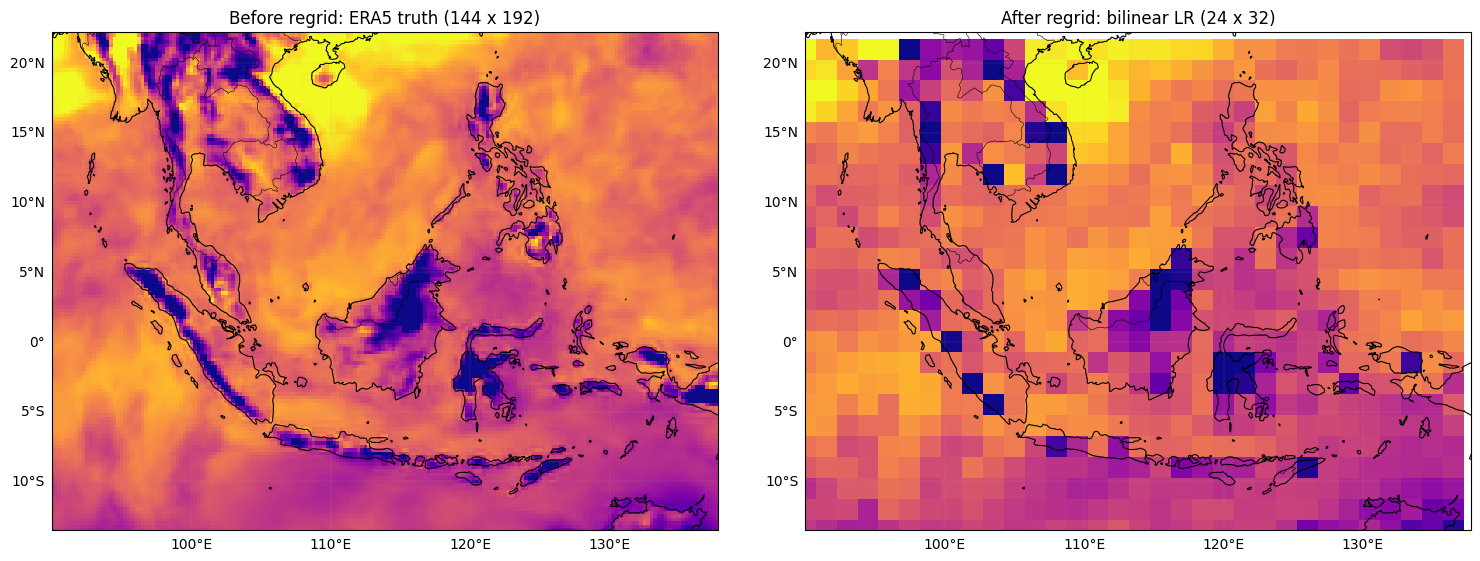

In [6]:
# Cartopy comparison: before regrid vs after regrid
plot_date = "2022-08-01"
plot_var = "2m_temperature"  # try: "total_precipitation_24hr", "10m_u_component_of_wind", "10m_v_component_of_wind"

def select_plot_day(ds, var_name, date):
    start = pd.Timestamp(date)
    end = start + pd.Timedelta(days=1) - pd.Timedelta(nanoseconds=1)
    da = ds[var_name].sel(time=slice(start, end))

    if da.sizes.get("time", 0) == 0:
        da = ds[var_name].sel(time=start, method="nearest")
    elif da.sizes["time"] > 1:
        da = da.mean("time")
    else:
        da = da.isel(time=0)

    return da.squeeze(drop=True)

def make_display_units(da):
    units = str(da.attrs.get("units", "")).lower()
    if units in {"k", "kelvin"}:
        da = da - 273.15
        da.attrs["units"] = "degC"
    return da

before = make_display_units(select_plot_day(ds_tr, plot_var, plot_date))
after = make_display_units(select_plot_day(ds_lr, plot_var, plot_date))

vmin, vmax = np.nanpercentile(
    np.concatenate([before.values.ravel(), after.values.ravel()]),
    [2, 98],
)

projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    ncols=2,
    figsize=(15, 5.5),
    subplot_kw={"projection": projection},
    constrained_layout=True,
)

plots = [
    (axes[0], before, f"Before regrid: ERA5 truth ({before.sizes['latitude']} x {before.sizes['longitude']})"),
    (axes[1], after, f"After regrid: bilinear LR ({after.sizes['latitude']} x {after.sizes['longitude']})"),
]

extent = [
    float(ds_tr.longitude.min()),
    float(ds_tr.longitude.max()),
    float(ds_tr.latitude.min()),
    float(ds_tr.latitude.max()),
]

for ax, da, title in plots:
    mesh = ax.pcolormesh(
        da.longitude,
        da.latitude,
        da,
        transform=projection,
        shading="auto",
        cmap="plasma",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_extent(extent, crs=projection)
    ax.coastlines(resolution="50m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    gl = ax.gridlines(draw_labels=True, linewidth=0.25, alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title(title)

# Show the target low-resolution grid points so the downsampling is visible.
lr_lon2d, lr_lat2d = np.meshgrid(ds_lr.longitude.values, ds_lr.latitude.values)
axes[1].pcolormesh(
    ds_lr.longitude,
    ds_lr.latitude,
    np.full_like(ds_lr.latitude.values[:, None], np.nan),
    transform=projection,
    shading="auto",
    cmap="plasma",
    vmin=vmin,
    vmax=vmax,
)
axes[1].legend(loc="lower left", fontsize=8, frameon=True)

units = after.attrs.get("units", plot_var)
fig.colorbar(mesh, ax=axes, orientation="horizontal", shrink=0.75, pad=0.06, label=units)
fig.suptitle(f"{plot_var} on {plot_date}: before and after HR -> LR regrid", fontsize=14)
plt.show()


In [ ]:
ds_full = xr.open_zarr('gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr')
ds_full

Could not determine bucket type for bucket name weatherbench2: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information.
Could not determine bucket type for bucket name weatherbench2: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information.
Could not determine bucket type for bucket name weatherbench2: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information.
Could not determine bucket type for bucket name weatherbench2: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information.


KeyboardInterrupt: 

In [ ]:
# Compare full-globe ERA5 (WeatherBench2) vs cropped truth domain (ds_tr)
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

preferred_vars = [
    "2m_temperature",
    "total_precipitation_24hr",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
]

common_vars = [v for v in preferred_vars if v in ds_full.data_vars and v in ds_tr.data_vars]
if not common_vars:
    common_vars = sorted(set(ds_full.data_vars).intersection(set(ds_tr.data_vars)))

if not common_vars:
    raise ValueError("No common variable found between ds_full and ds_tr")

plot_var = common_vars[0]
target_time = pd.Timestamp(ds_tr.time.values[0])

da_global = ds_full[plot_var].sel(time=target_time, method="nearest")
da_crop = ds_tr[plot_var].sel(time=target_time, method="nearest")

# If variable has vertical levels, pick near-surface level for display consistency.
if "level" in da_global.dims:
    da_global = da_global.sel(level=1000, method="nearest")
if "level" in da_crop.dims:
    da_crop = da_crop.sel(level=1000, method="nearest")

def to_display_units(da):
    units = str(da.attrs.get("units", "")).lower()
    if units in {"k", "kelvin"}:
        da = da - 273.15
        da.attrs["units"] = "degC"
    return da

da_global = to_display_units(da_global).squeeze(drop=True)
da_crop = to_display_units(da_crop).squeeze(drop=True)

vmin, vmax = np.nanpercentile(
    np.concatenate([da_global.values.ravel(), da_crop.values.ravel()]),
    [2, 98],
)

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    ncols=2,
    figsize=(17, 6),
    subplot_kw={"projection": proj},
    constrained_layout=True,
)

# Left: full globe
mesh_global = axes[0].pcolormesh(
    da_global.longitude,
    da_global.latitude,
    da_global,
    transform=proj,
    shading="auto",
    cmap="turbo",
    vmin=vmin,
    vmax=vmax,
 )
axes[0].set_global()
axes[0].coastlines(resolution="110m", linewidth=0.7)
axes[0].add_feature(cfeature.BORDERS, linewidth=0.3)
axes[0].set_title(f"Global {plot_var} ({str(da_global.time.values)[:19]})")

# Draw crop bounding box on global map
lon_min = float(ds_tr.longitude.min())
lon_max = float(ds_tr.longitude.max())
lat_min = float(ds_tr.latitude.min())
lat_max = float(ds_tr.latitude.max())

bbox_lon = [lon_min, lon_max, lon_max, lon_min, lon_min]
bbox_lat = [lat_min, lat_min, lat_max, lat_max, lat_min]
axes[0].plot(bbox_lon, bbox_lat, color="black", linewidth=1.2, transform=proj)

# Right: cropped truth domain
mesh_crop = axes[1].pcolormesh(
    da_crop.longitude,
    da_crop.latitude,
    da_crop,
    transform=proj,
    shading="auto",
    cmap="turbo",
    vmin=vmin,
    vmax=vmax,
 )
axes[1].set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
axes[1].coastlines(resolution="50m", linewidth=0.8)
axes[1].add_feature(cfeature.BORDERS, linewidth=0.4)
grid = axes[1].gridlines(draw_labels=True, linewidth=0.25, alpha=0.5, linestyle="--")
grid.top_labels = False
grid.right_labels = False
axes[1].set_title(f"Cropped truth domain ({da_crop.sizes['latitude']} x {da_crop.sizes['longitude']})")

units = da_crop.attrs.get("units", plot_var)
fig.colorbar(mesh_crop, ax=axes, orientation="horizontal", shrink=0.8, pad=0.06, label=units)
fig.suptitle(f"Full globe vs cropped truth: {plot_var}", fontsize=14)
plt.show()

print(f"Variable: {plot_var}")
print(f"Global time selected: {pd.Timestamp(da_global.time.values)}")
print(f"Cropped time selected: {pd.Timestamp(da_crop.time.values)}")

NameError: name 'ds_full' is not defined

In [ ]:
ds_tr

<xarray.Dataset> Size: 3GB
Dimensions:                   (time: 7304, latitude: 144, longitude: 192)
Coordinates:
  * latitude                  (latitude) float32 576B -13.5 -13.25 ... 22.25
  * longitude                 (longitude) float32 768B 90.0 90.25 ... 137.8
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 808MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    10m_v_component_of_wind   (time, latitude, longitude) float32 808MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    2m_temperature            (time, latitude, longitude) float32 808MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    total_precipitation_24hr  (time, latitude, longitude) float32 808MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>

In [ ]:
zarr_path = "data/ifs_lowres_indonesia_2018-2022.zarr"
ds_lr = xr.open_zarr(zarr_path, consolidated=True)
ds_lr

C:\Users\zharif\AppData\Local\Temp\ipykernel_21276\2157975360.py:2: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_lr = xr.open_zarr(zarr_path, consolidated=True)


<xarray.Dataset> Size: 4GB
Dimensions:                   (time: 3652, prediction_timedelta: 61,
                               longitude: 41, latitude: 30)
Coordinates:
  * latitude                  (latitude) float64 240B -13.5 -12.0 ... 28.5 30.0
  * longitude                 (longitude) float64 328B 90.0 91.5 ... 148.5 150.0
  * prediction_timedelta      (prediction_timedelta) timedelta64[ns] 488B 00:...
  * time                      (time) datetime64[ns] 29kB 2018-01-01 ... 2022-...
Data variables:
    10m_u_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 1GB dask.array<chunksize=(1, 8, 41, 30), meta=np.ndarray>
    10m_v_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 1GB dask.array<chunksize=(1, 8, 41, 30), meta=np.ndarray>
    2m_temperature            (time, prediction_timedelta, longitude, latitude) float32 1GB dask.array<chunksize=(1, 8, 41, 30), meta=np.ndarray>
    total_precipitation_24hr  (time, prediction_timedelta, longitude, latitude) float32 1GB dask.array<chunksize=(1, 8, 41, 30), meta=np.ndarray>

In [ ]:
import numpy as np

def check_nan_summary(ds, name):
    print(f"\n==== {name} ====")
    for var in ds.data_vars:
        data = ds[var].values
        total = data.size
        n_nan = np.isnan(data).sum()
        pct = (n_nan / total) * 100
        print(f"{var:30s} | NaNs: {n_nan:10d} | {pct:.5f}%")

check_nan_summary(ds_hr, "ERA5")
check_nan_summary(ds_lr, "ECMWF IFS")


==== ERA5 ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%

==== ECMWF IFS ====
10m_u_component_of_wind        | NaNs:      75030 | 0.02738%
10m_v_component_of_wind        | NaNs:      75030 | 0.02738%
2m_temperature                 | NaNs:      75030 | 0.02738%
total_precipitation_24hr       | NaNs:   18037950 | 6.58296%


In [ ]:
ds_lr_clean = ds_lr.drop_sel(time=pd.to_datetime(['2019-10-17T00:00:00.000000000']), errors='ignore')
ds_lr_clean = ds_lr_clean.drop_sel(prediction_timedelta=np.timedelta64(0, 'D'), errors='ignore')
check_nan_summary(ds_lr_clean, "ECMWF IFS")


==== ECMWF IFS ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:   13472190 | 5.00000%


In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display

var_name = "total_precipitation_24hr"
da = ds_lr[var_name]
mask = da.isnull()
total_nulls = int(mask.sum().compute().item())

print(f"{var_name}: {total_nulls} null values")

if total_nulls == 0:
    print("No null values found.")
else:
    if "time" in da.dims:
        other_dims = [dim for dim in da.dims if dim != "time"]
        time_counts = mask.sum(dim=other_dims).to_series()
        time_counts = time_counts[time_counts > 0].sort_values(ascending=False)
        print("\nNulls by time step:")
        display(time_counts.to_frame(name="null_count"))

    slice_indexers = {dim: 0 for dim in ("time", "prediction_timedelta") if dim in da.dims}
    sample_mask = mask.isel(**slice_indexers).compute()
    null_idx = np.argwhere(sample_mask.values)

    print(f"\nNull indices for sample slice {slice_indexers or '{}'}:")
    if null_idx.size == 0:
        print("No nulls in the sample slice.")
    else:
        null_df = pd.DataFrame(null_idx, columns=[f"{dim}_idx" for dim in sample_mask.dims])
        print(null_df.head(20).to_string(index=False))

total_precipitation_24hr: 18037950 null values

Nulls by time step:


,null_count
time,
2019-10-17 00:00:00,75030
2018-01-03 00:00:00,4920
2022-12-31 12:00:00,4920
2018-01-01 00:00:00,4920
2018-01-01 12:00:00,4920
...,...
2018-01-08 12:00:00,4920
2018-01-09 00:00:00,4920
2018-01-09 12:00:00,4920



Null indices for sample slice {'time': 0, 'prediction_timedelta': 0}:
 longitude_idx  latitude_idx
             0             0
             0             1
             0             2
             0             3
             0             4
             0             5
             0             6
             0             7
             0             8
             0             9
             0            10
             0            11
             0            12
             0            13
             0            14
             0            15
             0            16
             0            17
             0            18
             0            19


In [ ]:
from IPython.display import display

var_name = "total_precipitation_24hr"
da = ds_lr[var_name]
mask = da.isnull()

if "prediction_timedelta" not in da.dims:
    print(f"{var_name} does not have a prediction_timedelta dimension.")
else:
    other_dims = [dim for dim in da.dims if dim != "prediction_timedelta"]
    pred_counts = mask.sum(dim=other_dims).compute().to_series()
    pred_counts = pred_counts[pred_counts > 0]

    print(f"{var_name}: null values per prediction_timedelta")
    display(pred_counts.to_frame(name="null_count"))

total_precipitation_24hr: null values per prediction_timedelta


,null_count
prediction_timedelta,
0 days 00:00:00,4491960
0 days 06:00:00,4491960
0 days 12:00:00,4491960
0 days 18:00:00,4491960
1 days 00:00:00,1230
...,...
14 days 00:00:00,1230
14 days 06:00:00,1230
14 days 12:00:00,1230


In [ ]:
from IPython.display import display

var_name = "total_precipitation_24hr"
focus_time = None
focus_prediction_timedelta = None

da = ds_lr[var_name]
mask = da.isnull()

if "time" not in da.dims or "prediction_timedelta" not in da.dims:
    print(f"{var_name} does not have both time and prediction_timedelta dimensions.")
else:
    other_dims = [dim for dim in da.dims if dim not in {"time", "prediction_timedelta"}]
    null_by_time_pred = mask.sum(dim=other_dims).compute().to_pandas()

    if focus_time is not None:
        focus_time = pd.Timestamp(focus_time)
        null_by_time_pred = null_by_time_pred.loc[null_by_time_pred.index == focus_time]

    if focus_prediction_timedelta is not None:
        focus_prediction_timedelta = pd.to_timedelta(focus_prediction_timedelta)
        null_by_time_pred = null_by_time_pred.loc[:, null_by_time_pred.columns == focus_prediction_timedelta]

    time_totals = null_by_time_pred.sum(axis=1).sort_values(ascending=False)
    pred_totals = null_by_time_pred.sum(axis=0).sort_values(ascending=False)

    print(f"{var_name}: null value summary by time and prediction_timedelta")
    print("\nTop time steps by total nulls:")
    display(time_totals.to_frame(name="null_count"))

    print("\nTop prediction_timedelta values by total nulls:")
    display(pred_totals.to_frame(name="null_count"))

    print("\nCompact null counts table (top 10 times x top 10 prediction_timedelta values):")
    display(null_by_time_pred.loc[time_totals.head(10).index, pred_totals.head(10).index])

total_precipitation_24hr: null value summary by time and prediction_timedelta

Top time steps by total nulls:


,null_count
time,
2019-10-17 00:00:00,75030
2018-01-03 00:00:00,4920
2022-12-31 12:00:00,4920
2018-01-01 00:00:00,4920
2018-01-01 12:00:00,4920
...,...
2018-01-08 12:00:00,4920
2018-01-09 00:00:00,4920
2018-01-09 12:00:00,4920



Top prediction_timedelta values by total nulls:


,null_count
prediction_timedelta,
0 days 00:00:00,4491960
0 days 06:00:00,4491960
0 days 12:00:00,4491960
0 days 18:00:00,4491960
1 days 00:00:00,1230
...,...
14 days 00:00:00,1230
14 days 06:00:00,1230
14 days 12:00:00,1230



Compact null counts table (top 10 times x top 10 prediction_timedelta values):


prediction_timedelta,0 days 00:00:00,0 days 06:00:00,0 days 12:00:00,0 days 18:00:00,1 days 00:00:00,1 days 06:00:00,1 days 12:00:00,1 days 18:00:00,2 days 00:00:00,2 days 06:00:00
time,,,,,,,,,,
2019-10-17 00:00:00,1230,1230,1230,1230,1230,1230,1230,1230,1230,1230
2018-01-03 00:00:00,1230,1230,1230,1230,0,0,0,0,0,0
2022-12-31 12:00:00,1230,1230,1230,1230,0,0,0,0,0,0
2018-01-01 00:00:00,1230,1230,1230,1230,0,0,0,0,0,0
2018-01-01 12:00:00,1230,1230,1230,1230,0,0,0,0,0,0
2022-12-24 00:00:00,1230,1230,1230,1230,0,0,0,0,0,0
2022-12-16 12:00:00,1230,1230,1230,1230,0,0,0,0,0,0
2022-12-17 00:00:00,1230,1230,1230,1230,0,0,0,0,0,0
2022-12-17 12:00:00,1230,1230,1230,1230,0,0,0,0,0,0


Sample shape used for plots: (64, 4, 24, 32)
Only precipitation uses log1p; other variables are standardized directly.
Per-channel stats after precipitation log1p:
  10m_u_component_of_wind: mean=-1.0502, std=4.6632
  10m_v_component_of_wind: mean=-1.8389, std=3.3582
  2m_temperature: mean=298.9957, std=2.7619
  total_precipitation_24hr: mean=0.0088, std=0.0129


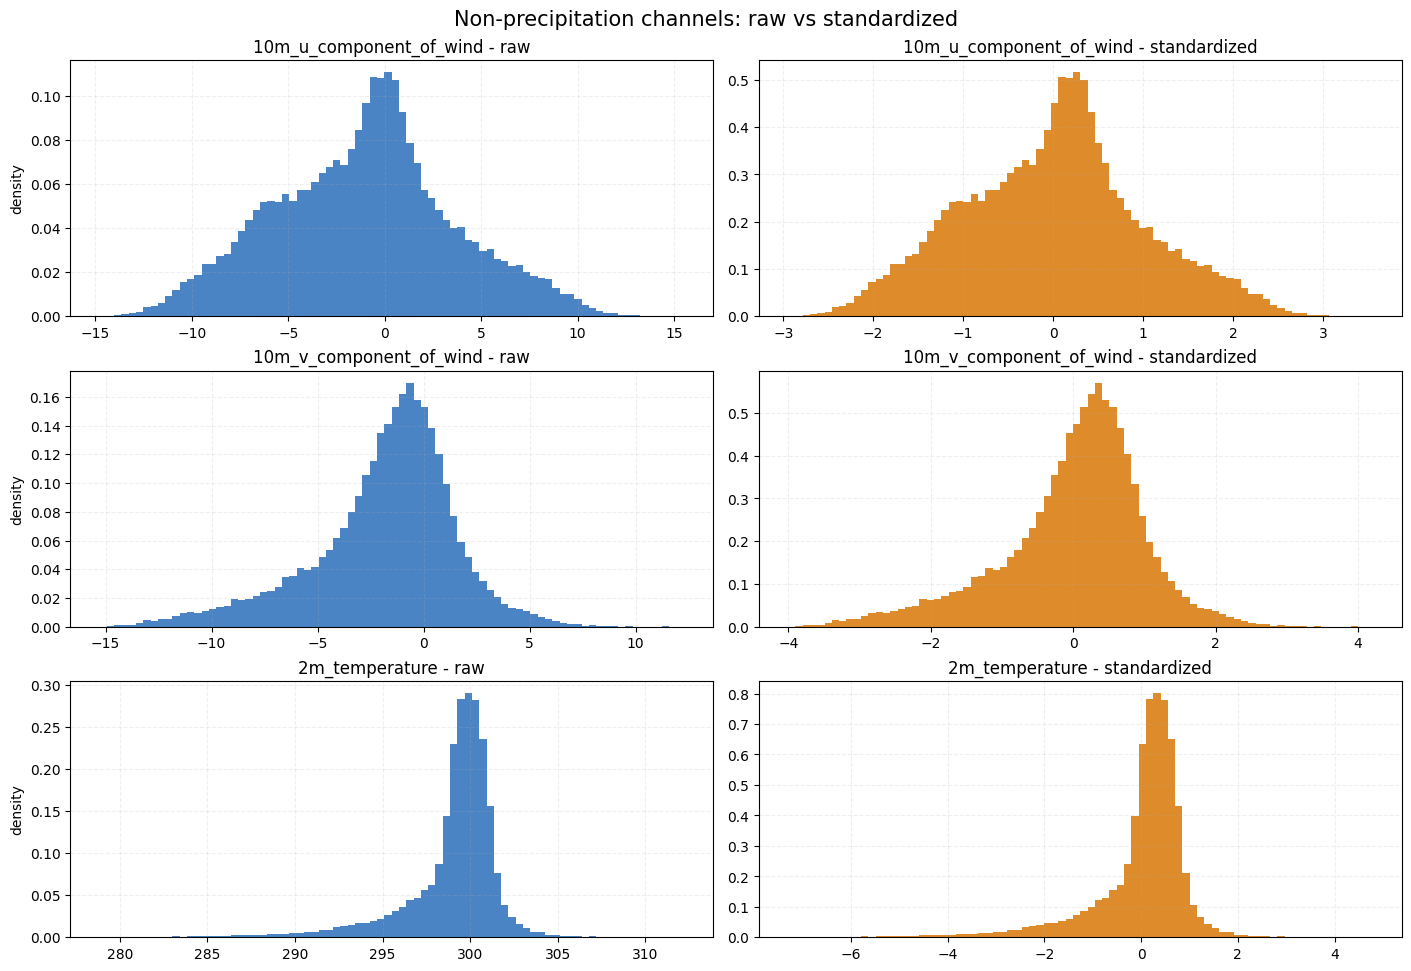

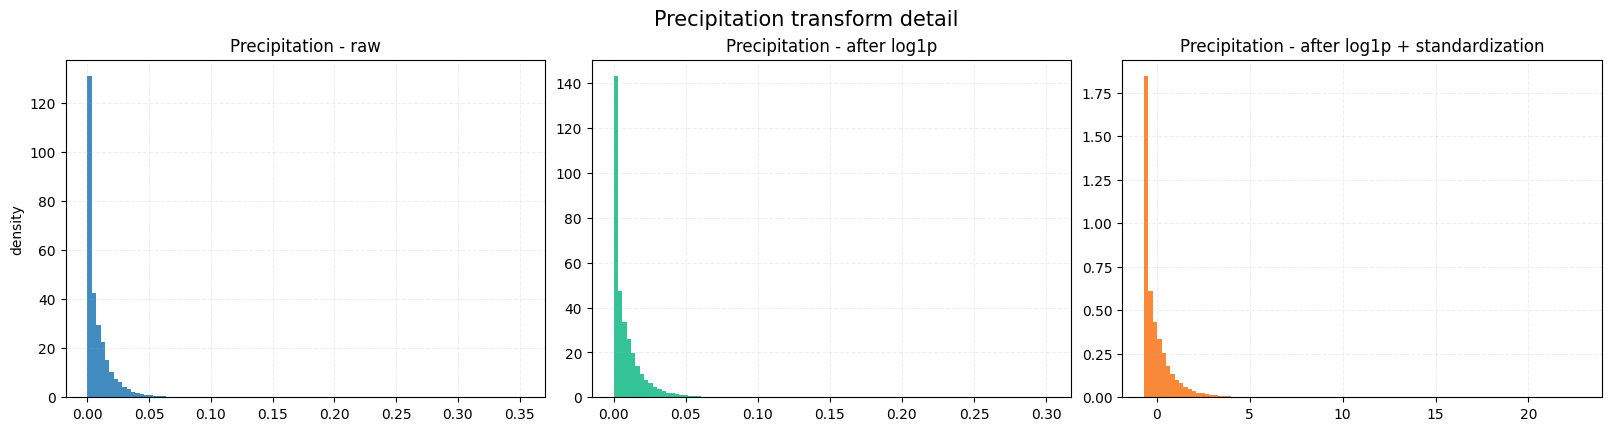

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

VARS = [
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_temperature",
    "total_precipitation_24hr",
]
TP_IDX = VARS.index("total_precipitation_24hr")
SAMPLE_TIME_STEPS = 64


def _select_lead_and_sample(ds, variables, time_steps=SAMPLE_TIME_STEPS):
    sample = ds
    if "prediction_timedelta" in sample.dims:
        lead_values = sample.prediction_timedelta.values
        lead_zero = np.timedelta64(0, "D")
        lead_value = lead_zero if lead_zero in lead_values else lead_values[0]
        sample = sample.sel(prediction_timedelta=lead_value)

    if "time" in sample.dims:
        sample = sample.isel(time=slice(0, min(time_steps, sample.sizes["time"])))

    arrays = np.stack([sample[var].values for var in variables], axis=1).astype(np.float32)
    return arrays


X_raw = _select_lead_and_sample(ds_fc, VARS)
X_proc = X_raw.copy()
X_proc[:, TP_IDX] = np.log1p(np.clip(X_proc[:, TP_IDX], 0, None))

X_mean = X_proc.mean(axis=(0, 2, 3), keepdims=True)
X_std = X_proc.std(axis=(0, 2, 3), keepdims=True)
X_stdzd = (X_proc - X_mean) / (X_std + 1e-6)

print(f"Sample shape used for plots: {X_raw.shape}")
print("Only precipitation uses log1p; other variables are standardized directly.")
print("Per-channel stats after precipitation log1p:")
for i, var in enumerate(VARS):
    print(f"  {var}: mean={X_mean[0, i, 0, 0]:.4f}, std={X_std[0, i, 0, 0]:.4f}")

fig, axes = plt.subplots(3, 2, figsize=(14, 9.6), constrained_layout=True)
non_precip_vars = VARS[:TP_IDX]

for i, var in enumerate(non_precip_vars):
    raw = X_raw[:, i].ravel()
    stdzd = X_stdzd[:, i].ravel()

    raw = raw[np.isfinite(raw)]
    stdzd = stdzd[np.isfinite(stdzd)]

    axes[i, 0].hist(raw, bins=80, density=True, color="#2a6fbb", alpha=0.85)
    axes[i, 0].set_title(f"{var} - raw")
    axes[i, 0].set_ylabel("density")

    axes[i, 1].hist(stdzd, bins=80, density=True, color="#d97706", alpha=0.85)
    axes[i, 1].set_title(f"{var} - standardized")

    for ax in axes[i]:
        ax.grid(True, alpha=0.2, linestyle="--")

fig.suptitle("Non-precipitation channels: raw vs standardized", fontsize=15)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), constrained_layout=True)

prec_raw = X_raw[:, TP_IDX].ravel()
prec_log = X_proc[:, TP_IDX].ravel()
prec_std = X_stdzd[:, TP_IDX].ravel()

prec_raw = prec_raw[np.isfinite(prec_raw)]
prec_log = prec_log[np.isfinite(prec_log)]
prec_std = prec_std[np.isfinite(prec_std)]

axes[0].hist(prec_raw, bins=100, density=True, color="#1f77b4", alpha=0.85)
axes[0].set_title("Precipitation - raw")
axes[0].set_ylabel("density")

axes[1].hist(prec_log, bins=100, density=True, color="#10b981", alpha=0.85)
axes[1].set_title("Precipitation - after log1p")

axes[2].hist(prec_std, bins=100, density=True, color="#f97316", alpha=0.85)
axes[2].set_title("Precipitation - after log1p + standardization")

for ax in axes:
    ax.grid(True, alpha=0.2, linestyle="--")

fig.suptitle("Precipitation transform detail", fontsize=15)
plt.show()

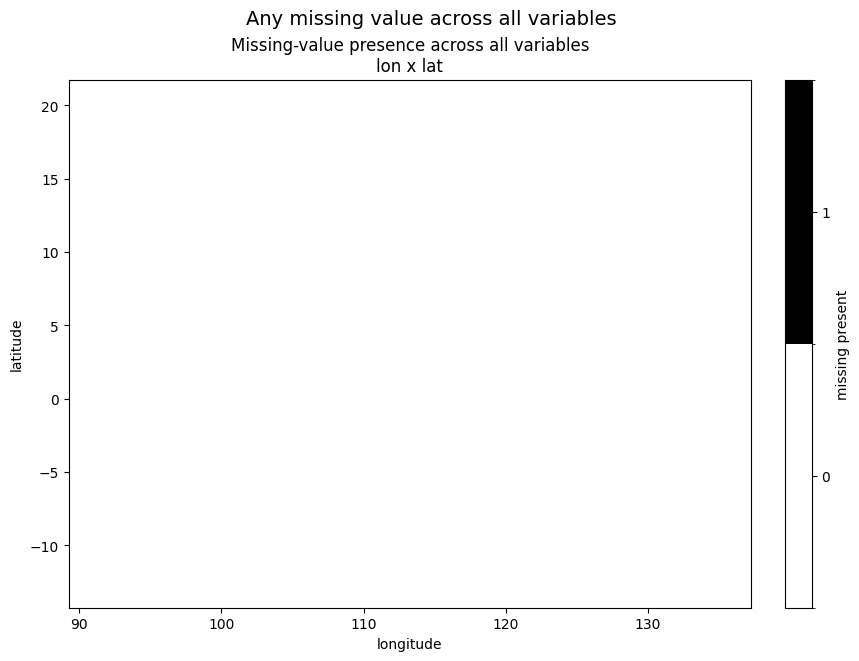

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Aggregate missing-value presence across all data variables in ds_fc.
mask = None
for var_name in ds_fc.data_vars:
    var_mask = ds_fc[var_name].isnull()
    count_dims = [dim for dim in var_mask.dims if dim not in {"longitude", "latitude"}]
    var_presence = var_mask.any(dim=count_dims)
    mask = var_presence if mask is None else (mask | var_presence)

mask = mask.compute().astype(int)
lon = ds_fc.longitude.values
lat = ds_fc.latitude.values
count_values = mask.values

cmap = ListedColormap(["white", "black"])
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

fig, ax = plt.subplots(1, 1, figsize=(8.5, 6.5), constrained_layout=True)
mesh = ax.pcolormesh(
    lon,
    lat,
    count_values,
    shading="auto",
    cmap=cmap,
    norm=norm,
)
ax.set_title("Missing-value presence across all variables\nlon x lat")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
fig.colorbar(
    mesh,
    ax=ax,
    label="missing present",
    ticks=[0, 1],
)
fig.suptitle("Any missing value across all variables", fontsize=14)
plt.show()